# Exploration
This notebook explores explainable AI techniques using the German Credit Data dataset.

## Libraries

### Installation

In [2]:
%pip install pandas numpy requests jupyter matplotlib scikit-learn

  Using cached numpy-2.4.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-macosx_10_13_universal2.whl.metadata (37 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached notebook-7.5.3-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.16.6-py3-none-any.whl.metadata (8.5 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.5.3-py3-none-any.whl.metadata (1

### Import

In [37]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import zipfile
import os
import matplotlib.pyplot as plt

## Functions

### Map Categorical Value

In [38]:
def map_categorical_value(code, column_index):
    """
    Maps a single categorical code to its actual meaning
    
    Args:
        code (str): The categorical code (e.g., 'A11', 'A23')
        column_index (int): The column index in the dataframe (0-based)
    
    Returns:
        str: The actual meaning of the code, or the original code if not found
    """
    mappings = get_feature_mappings()
    
    if column_index in mappings and code in mappings[column_index]:
        return mappings[column_index][code]
    else:
        return code  # Return original code if mapping not found

### Transform Dataframe With Labels

In [39]:
def transform_dataframe_with_labels(df):
    """
    Transforms the entire dataframe by replacing categorical codes with actual meanings
    
    Args:
        df (pd.DataFrame): The original dataframe with categorical codes
    
    Returns:
        pd.DataFrame: A new dataframe with readable labels
    """
    # Create a copy of the dataframe
    df_transformed = df.copy()
    
    # Get the mappings
    mappings = get_feature_mappings()
    
    # Apply mappings to categorical columns
    for column_index, mapping_dict in mappings.items():
        if column_index < len(df.columns):
            df_transformed.iloc[:, column_index] = df_transformed.iloc[:, column_index].map(mapping_dict).fillna(df_transformed.iloc[:, column_index])
    
    return df_transformed

### Add column names

In [40]:
def add_column_names(df):
    """
    Adds proper column names to the dataframe
    
    Args:
        df (pd.DataFrame): The dataframe to add column names to
    
    Returns:
        pd.DataFrame: Dataframe with proper column names
    """
    column_names = [
        'checking_account_status',    # Attribute 1
        'duration_months',            # Attribute 2
        'credit_history',            # Attribute 3
        'purpose',                   # Attribute 4
        'credit_amount',             # Attribute 5
        'savings_account',           # Attribute 6
        'employment_since',          # Attribute 7
        'installment_rate',          # Attribute 8
        'personal_status_sex',       # Attribute 9
        'other_debtors',             # Attribute 10
        'residence_since',           # Attribute 11
        'property',                  # Attribute 12
        'age_years',                 # Attribute 13
        'other_installment_plans',   # Attribute 14
        'housing',                   # Attribute 15
        'existing_credits',          # Attribute 16
        'job',                       # Attribute 17
        'num_dependents',            # Attribute 18
        'telephone',                 # Attribute 19
        'foreign_worker',            # Attribute 20
        'class'                      # Target variable (1=good, 2=bad)
    ]
    
    df_named = df.copy()
    df_named.columns = column_names
    
    return df_named

### Get Feature Mappings

In [41]:
# Define mapping dictionaries for categorical features
def get_feature_mappings():
    """Returns a dictionary containing all feature mappings"""
    
    mappings = {
        # Attribute 1: Status of existing checking account
        0: {
            'A11': '< 0 DM',
            'A12': '0 <= ... < 200 DM', 
            'A13': '>= 200 DM / salary assignments for at least 1 year',
            'A14': 'no checking account'
        },
        
        # Attribute 3: Credit history
        2: {
            'A30': 'no credits taken / all credits paid back duly',
            'A31': 'all credits at this bank paid back duly',
            'A32': 'existing credits paid back duly till now',
            'A33': 'delay in paying off in the past',
            'A34': 'critical account / other credits existing (not at this bank)'
        },
        
        # Attribute 4: Purpose
        3: {
            'A40': 'car (new)',
            'A41': 'car (used)',
            'A42': 'furniture/equipment',
            'A43': 'radio/television',
            'A44': 'domestic appliances',
            'A45': 'repairs',
            'A46': 'education',
            'A48': 'retraining',
            'A49': 'business',
            'A410': 'others'
        },
        
        # Attribute 6: Savings account/bonds
        5: {
            'A61': '< 100 DM',
            'A62': '100 <= ... < 500 DM',
            'A63': '500 <= ... < 1000 DM',
            'A64': '>= 1000 DM',
            'A65': 'unknown / no savings account'
        },
        
        # Attribute 7: Present employment since
        6: {
            'A71': 'unemployed',
            'A72': '< 1 year',
            'A73': '1 <= ... < 4 years',
            'A74': '4 <= ... < 7 years',
            'A75': '>= 7 years'
        },
        
        # Attribute 9: Personal status and sex
        8: {
            'A91': 'male : divorced/separated',
            'A92': 'female : divorced/separated/married',
            'A93': 'male : single',
            'A94': 'male : married/widowed',
            'A95': 'female : single'
        },
        
        # Attribute 10: Other debtors / guarantors
        9: {
            'A101': 'none',
            'A102': 'co-applicant',
            'A103': 'guarantor'
        },
        
        # Attribute 12: Property
        11: {
            'A121': 'real estate',
            'A122': 'building society savings agreement / life insurance',
            'A123': 'car or other, not in attribute 6',
            'A124': 'unknown / no property'
        },
        
        # Attribute 14: Other installment plans
        13: {
            'A141': 'bank',
            'A142': 'stores',
            'A143': 'none'
        },
        
        # Attribute 15: Housing
        14: {
            'A151': 'rent',
            'A152': 'own',
            'A153': 'for free'
        },
        
        # Attribute 17: Job
        16: {
            'A171': 'unemployed / unskilled - non-resident',
            'A172': 'unskilled - resident',
            'A173': 'skilled employee / official',
            'A174': 'management / self-employed / highly qualified employee / officer'
        },
        
        # Attribute 19: Telephone
        18: {
            'A191': 'none',
            'A192': 'yes, registered under the customers name'
        },
        
        # Attribute 20: Foreign worker
        19: {
            'A201': 'yes',
            'A202': 'no'
        }
    }
    
    return mappings

## Getting data

In [42]:
# Download German Credit Data from UCI ML Repository
url = "https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip"

# Download the zip file
response = requests.get(url)
response.raise_for_status()

# Extract the zip file and load data into DataFrame
from io import BytesIO
with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    # List files in the zip
    file_list = zip_file.namelist()
    print("Files in the dataset:")
    for file in file_list:
        print(f"  {file}")
    
    # Find the main data file (usually german.data)
    data_file = None
    for file in file_list:
        if file.endswith('.data') or 'german' in file.lower():
            data_file = file
            break
    
    if data_file:
        with zip_file.open(data_file) as f:
            # Read the data file
            data_content = f.read().decode('utf-8')
            
            # Load into pandas DataFrame
            # German credit data is space-separated
            df = pd.read_csv(StringIO(data_content), sep=' ', header=None)
            
            print(f"\nDataset loaded successfully!")
            print(f"Dataset shape: {df.shape}")
            print(f"\nFirst few rows:")
            print(df.head())
            print(f"\nData types:")
            print(df.dtypes)
    else:
        print("Could not find the main data file in the zip archive")

Files in the dataset:
  german.data
  german.data-numeric
  german.doc
  Index

Dataset loaded successfully!
Dataset shape: (1000, 21)

First few rows:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]

Data types:
0       str
1     int64
2       str
3       str
4     int64
5       str
6       str
7     int64
8       str
9       str
10    int64
1

## Transforming Dataframe

In [43]:
# Step 1: Adding proper column names
df_named = add_column_names(df)

# Step 2: Transforming all categorical values
df_transformed = transform_dataframe_with_labels(df_named)

df_transformed.head(10)

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,class
0,< 0 DM,6,critical account / other credits existing (not...,radio/television,1169,unknown / no savings account,>= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account / other credits existing (not...,education,2096,< 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement / life insu...,45,none,for free,1,skilled employee / official,2,none,yes,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2
5,no checking account,36,existing credits paid back duly till now,education,9055,unknown / no savings account,1 <= ... < 4 years,2,male : single,none,...,unknown / no property,35,none,for free,1,unskilled - resident,2,"yes, registered under the customers name",yes,1
6,no checking account,24,existing credits paid back duly till now,furniture/equipment,2835,500 <= ... < 1000 DM,>= 7 years,3,male : single,none,...,building society savings agreement / life insu...,53,none,own,1,skilled employee / official,1,none,yes,1
7,0 <= ... < 200 DM,36,existing credits paid back duly till now,car (used),6948,< 100 DM,1 <= ... < 4 years,2,male : single,none,...,"car or other, not in attribute 6",35,none,rent,1,management / self-employed / highly qualified ...,1,"yes, registered under the customers name",yes,1
8,no checking account,12,existing credits paid back duly till now,radio/television,3059,>= 1000 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,real estate,61,none,own,1,unskilled - resident,1,none,yes,1
9,0 <= ... < 200 DM,30,critical account / other credits existing (not...,car (new),5234,< 100 DM,unemployed,4,male : married/widowed,none,...,"car or other, not in attribute 6",28,none,own,2,management / self-employed / highly qualified ...,1,none,yes,2


In [ ]:
# Write csv
df_transformed.to_csv('data/credit_risk_transformed.csv', index=False)

## Visualization of Categorical Features

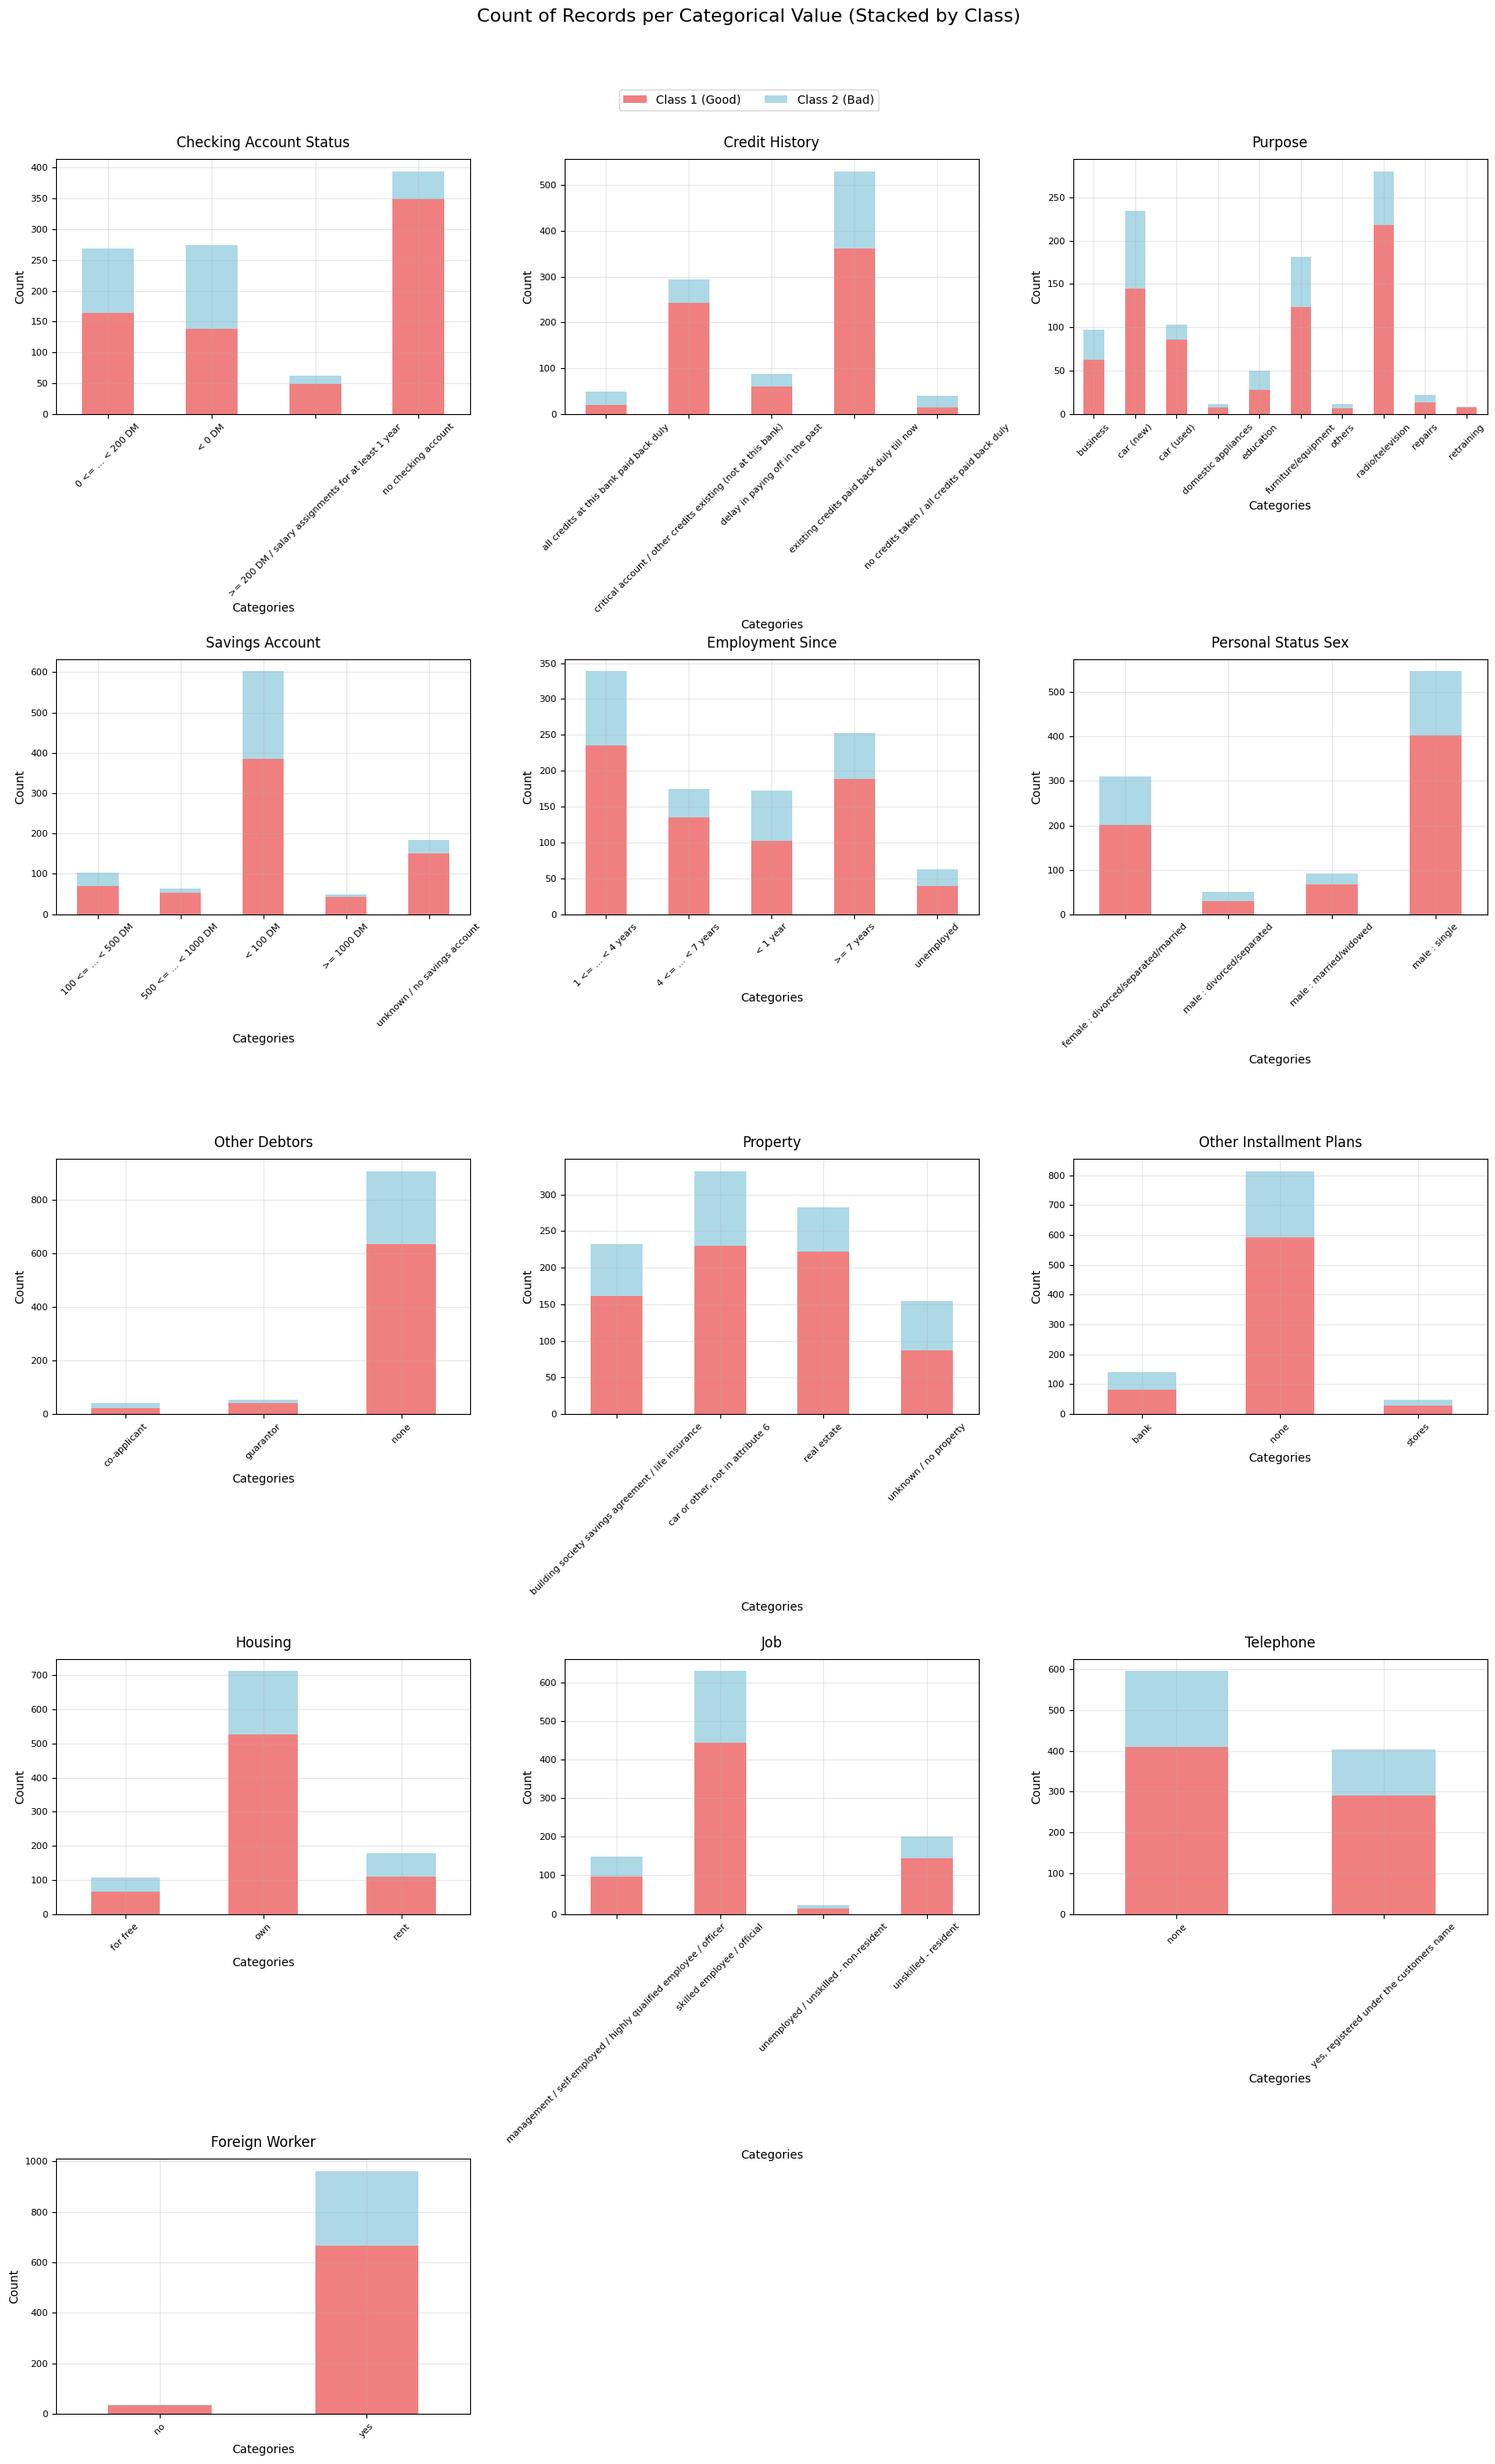

In [26]:
# Define categorical columns
categorical_columns = ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 
                      'employment_since', 'personal_status_sex', 'other_debtors', 'property',
                      'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

# Set up the grid plot
n_cols = 3  # Number of columns in the grid
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
fig.suptitle('Count of Records per Categorical Value (Stacked by Class)', fontsize=16, y=0.98)

# Flatten axes for easier iteration
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(categorical_columns):
    ax = axes_flat[i]
    
    # Create crosstab for stacking
    crosstab = pd.crosstab(df_transformed[col], df_transformed['class'])
    
    # Create stacked bar plot
    crosstab.plot(kind='bar', ax=ax, stacked=True, 
                  color=['lightcoral', 'lightblue'],
                  legend=False)  # Don't show individual legends
    
    # Customize the plot
    ax.set_title(f'{col.replace("_", " ").title()}', fontsize=12, pad=10)
    ax.set_xlabel('Categories', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(categorical_columns), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Add legend at the top
fig.legend(['Class 1 (Good)', 'Class 2 (Bad)'], 
           loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2)

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Make room for suptitle and legend
plt.show()

## Correlation Matrix of Numeric Features

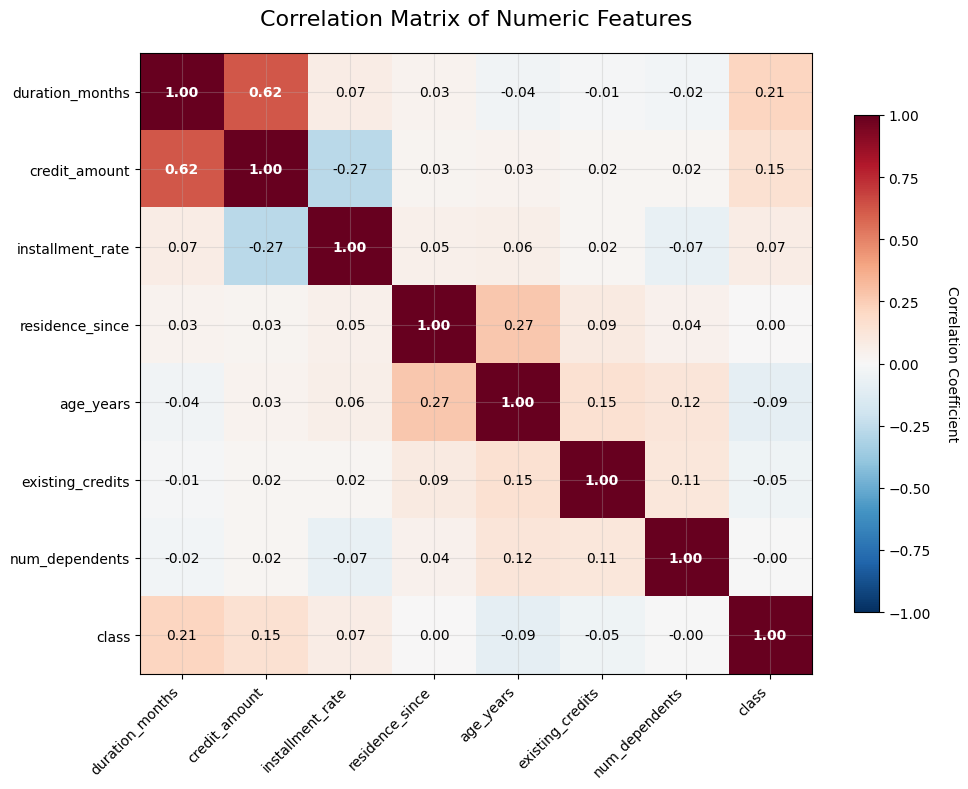

In [28]:
# Extract numeric columns from the transformed dataframe
numeric_columns = ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 
                   'age_years', 'existing_credits', 'num_dependents', 'class']

# Create a subset with only numeric features
df_numeric = df_transformed[numeric_columns]

# Calculate correlation matrix
correlation_matrix = df_numeric.corr()

# Create the correlation heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(shrink=0.8)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Set ticks and labels
plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=45, ha='right')
plt.yticks(range(len(numeric_columns)), numeric_columns)

# Add correlation values as text
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', 
                color='white' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'black',
                fontweight='bold' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'normal')

# Customize the plot
plt.title('Correlation Matrix of Numeric Features', fontsize=16, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Scatter Plot Matrix of Numeric Features (Colored by Class)

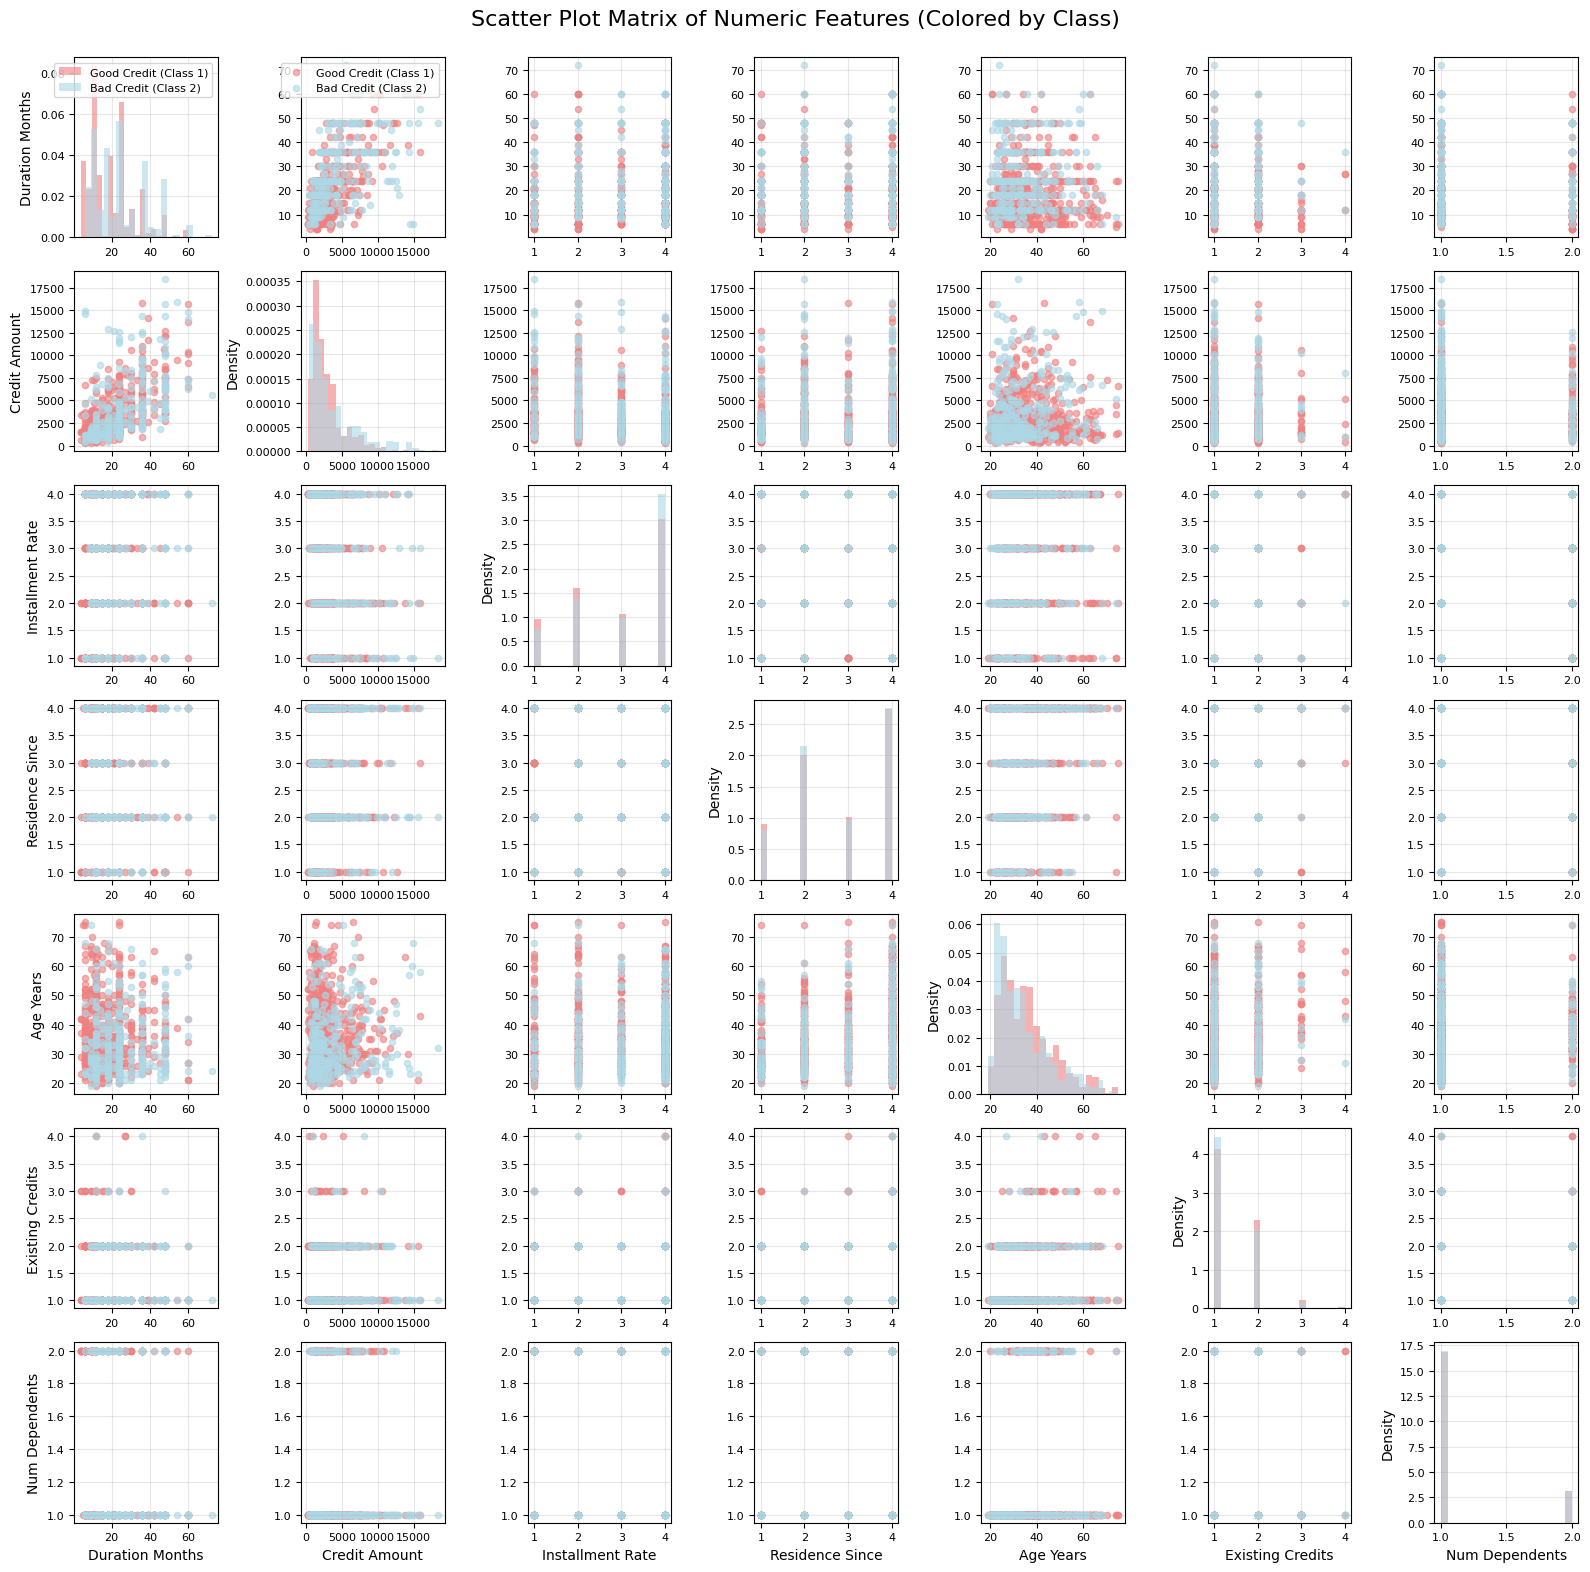

Summary Statistics by Class:

Class 1 (Good Credit (Class 1)):
----------------------------------------
       duration_months  credit_amount  installment_rate  residence_since  \
count           700.00         700.00            700.00           700.00   
mean             19.21        2985.46              2.92             2.84   
std              11.08        2401.47              1.13             1.11   
min               4.00         250.00              1.00             1.00   
25%              12.00        1375.50              2.00             2.00   
50%              18.00        2244.00              3.00             3.00   
75%              24.00        3634.75              4.00             4.00   
max              60.00       15857.00              4.00             4.00   

       age_years  existing_credits  num_dependents  
count     700.00            700.00          700.00  
mean       36.22              1.42            1.16  
std        11.38              0.58            0.36  

In [29]:
# Define numeric columns (excluding class for comparison)
numeric_features = ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 
                   'age_years', 'existing_credits', 'num_dependents']

# Number of features for grid
n_features = len(numeric_features)

# Create scatter plot matrix
fig, axes = plt.subplots(n_features, n_features, figsize=(16, 16))
fig.suptitle('Scatter Plot Matrix of Numeric Features (Colored by Class)', fontsize=16, y=0.98)

# Define colors for each class
class_colors = {1: 'lightcoral', 2: 'lightblue'}
class_labels = {1: 'Good Credit (Class 1)', 2: 'Bad Credit (Class 2)'}

# Create scatter plots for each pair of features
for i, feature_y in enumerate(numeric_features):
    for j, feature_x in enumerate(numeric_features):
        ax = axes[i, j]
        
        # If diagonal, create histogram instead of scatter plot
        if i == j:
            # Create histogram for each class
            for class_val in [1, 2]:
                class_data = df_transformed[df_transformed['class'] == class_val][feature_x]
                ax.hist(class_data, alpha=0.6, bins=20, 
                       color=class_colors[class_val], 
                       label=class_labels[class_val],
                       density=True)
            ax.set_ylabel('Density')
            if i == 0:  # Only show legend on first diagonal plot
                ax.legend(fontsize=8)
        else:
            # Create scatter plot for each class
            for class_val in [1, 2]:
                class_data = df_transformed[df_transformed['class'] == class_val]
                ax.scatter(class_data[feature_x], class_data[feature_y], 
                          alpha=0.6, s=20, 
                          color=class_colors[class_val],
                          label=class_labels[class_val] if i == 0 and j == 1 else "")
            
            # Add legend only to top-right scatter plot
            if i == 0 and j == 1:
                ax.legend(fontsize=8)
        
        # Set labels
        if i == n_features - 1:  # Bottom row
            ax.set_xlabel(feature_x.replace('_', ' ').title(), fontsize=10)
        if j == 0:  # Left column
            ax.set_ylabel(feature_y.replace('_', ' ').title(), fontsize=10)
            
        # Customize appearance
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Make room for suptitle
plt.show()

# Print summary statistics for each class
print("Summary Statistics by Class:")
print("=" * 60)
for class_val in [1, 2]:
    print(f"\nClass {class_val} ({class_labels[class_val]}):")
    print("-" * 40)
    class_stats = df_transformed[df_transformed['class'] == class_val][numeric_features].describe()
    print(class_stats.round(2))

In [ ]:
# Extract sex from personal_status_sex column
def extract_sex(personal_status_sex):
    """Extract sex from personal status and sex combined field"""
    if 'female' in personal_status_sex.lower():
        return 'Female'
    elif 'male' in personal_status_sex.lower():
        return 'Male'
    else:
        return 'Unknown'

# Add sex column to dataframe
df_transformed['sex'] = df_transformed['personal_status_sex'].apply(extract_sex)

# Verify the extraction
print("Sex extraction verification:")
print("=" * 50)
print("\nOriginal personal_status_sex values and extracted sex:")
for status in df_transformed['personal_status_sex'].unique():
    sex = extract_sex(status)
    print(f"'{status}' → '{sex}'")

print(f"\nSex distribution:")
print(df_transformed['sex'].value_counts())

print(f"\nCrosstab of sex vs class:")
crosstab_sex_class = pd.crosstab(df_transformed['sex'], df_transformed['class'])
print(crosstab_sex_class)

Sex extraction verification:

Original personal_status_sex values and extracted sex:
'male : single' → 'Female'
'female : divorced/separated/married' → 'Male'
'male : divorced/separated' → 'Female'
'male : married/widowed' → 'Female'

Sex distribution:
sex
Female    690
Male      310
Name: count, dtype: int64

Crosstab of sex vs class:
class     1    2
sex             
Female  499  191
Male    201  109


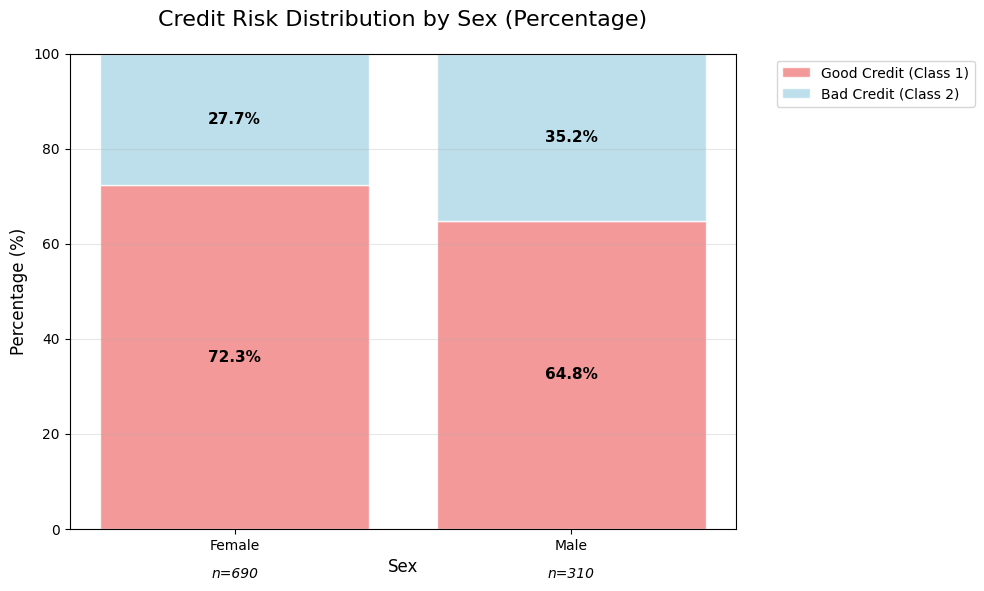


Detailed Statistics:

Percentage distribution by sex:
class      1     2
sex               
Female  72.3  27.7
Male    64.8  35.2

Absolute counts by sex:
class     1    2
sex             
Female  499  191
Male    201  109

Class distribution within each sex:

Female:
  Class 1: 499 people (72.3%)
  Class 2: 191 people (27.7%)
  Total: 690 people

Male:
  Class 1: 201 people (64.8%)
  Class 2: 109 people (35.2%)
  Total: 310 people


In [33]:
# Create percentage stacked bar plot by sex and class
crosstab_sex_class = pd.crosstab(df_transformed['sex'], df_transformed['class'])

# Calculate percentages
crosstab_percentage = crosstab_sex_class.div(crosstab_sex_class.sum(axis=1), axis=0) * 100

# Create the stacked percentage bar plot
plt.figure(figsize=(10, 6))

# Create stacked bars
bottom = np.zeros(len(crosstab_percentage.index))
colors = ['lightcoral', 'lightblue']
class_labels = ['Good Credit (Class 1)', 'Bad Credit (Class 2)']

for i, (class_val, color, label) in enumerate(zip([1, 2], colors, class_labels)):
    values = crosstab_percentage[class_val].values
    plt.bar(crosstab_percentage.index, values, bottom=bottom, 
            color=color, label=label, alpha=0.8, edgecolor='white', linewidth=1)
    
    # Add percentage labels on bars
    for j, (sex, value) in enumerate(zip(crosstab_percentage.index, values)):
        if value > 5:  # Only show label if percentage > 5%
            plt.text(j, bottom[j] + value/2, f'{value:.1f}%', 
                    ha='center', va='center', fontweight='bold', fontsize=11)
    
    bottom += values

# Customize the plot
plt.title('Credit Risk Distribution by Sex (Percentage)', fontsize=16, pad=20)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)

# Add count information as text below bars
for i, sex in enumerate(crosstab_percentage.index):
    total_count = crosstab_sex_class.loc[sex].sum()
    plt.text(i, -8, f'n={total_count}', ha='center', va='top', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print("=" * 50)
print(f"\nPercentage distribution by sex:")
print(crosstab_percentage.round(1))

print(f"\nAbsolute counts by sex:")
print(crosstab_sex_class)

print(f"\nClass distribution within each sex:")
for sex in crosstab_percentage.index:
    print(f"\n{sex}:")
    for class_val in [1, 2]:
        count = crosstab_sex_class.loc[sex, class_val]
        percentage = crosstab_percentage.loc[sex, class_val]
        print(f"  Class {class_val}: {count} people ({percentage:.1f}%)")
    print(f"  Total: {crosstab_sex_class.loc[sex].sum()} people")

## Foreign Worker Distribution Analysis

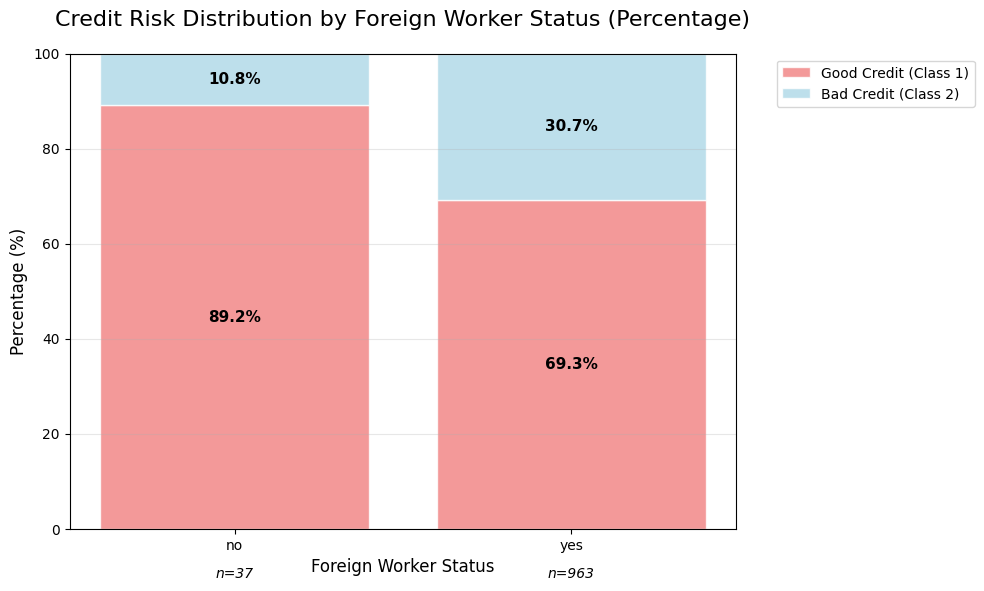


Detailed Statistics:

Foreign worker distribution:
foreign_worker
yes    963
no      37
Name: count, dtype: int64

Percentage distribution by foreign worker status:
class              1     2
foreign_worker            
no              89.2  10.8
yes             69.3  30.7

Absolute counts by foreign worker status:
class             1    2
foreign_worker          
no               33    4
yes             667  296

Class distribution within each foreign worker status:

no:
  Class 1: 33 people (89.2%)
  Class 2: 4 people (10.8%)
  Total: 37 people

yes:
  Class 1: 667 people (69.3%)
  Class 2: 296 people (30.7%)
  Total: 963 people


In [35]:
# Create percentage stacked bar plot by foreign_worker and class
crosstab_foreign_class = pd.crosstab(df_transformed['foreign_worker'], df_transformed['class'])

# Calculate percentages
crosstab_percentage = crosstab_foreign_class.div(crosstab_foreign_class.sum(axis=1), axis=0) * 100

# Create the stacked percentage bar plot
plt.figure(figsize=(10, 6))

# Create stacked bars
bottom = np.zeros(len(crosstab_percentage.index))
colors = ['lightcoral', 'lightblue']
class_labels = ['Good Credit (Class 1)', 'Bad Credit (Class 2)']

for i, (class_val, color, label) in enumerate(zip([1, 2], colors, class_labels)):
    values = crosstab_percentage[class_val].values
    plt.bar(crosstab_percentage.index, values, bottom=bottom, 
            color=color, label=label, alpha=0.8, edgecolor='white', linewidth=1)
    
    # Add percentage labels on bars
    for j, (foreign_status, value) in enumerate(zip(crosstab_percentage.index, values)):
        if value > 5:  # Only show label if percentage > 5%
            plt.text(j, bottom[j] + value/2, f'{value:.1f}%', 
                    ha='center', va='center', fontweight='bold', fontsize=11)
    
    bottom += values

# Customize the plot
plt.title('Credit Risk Distribution by Foreign Worker Status (Percentage)', fontsize=16, pad=20)
plt.xlabel('Foreign Worker Status', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)

# Add count information as text below bars
for i, foreign_status in enumerate(crosstab_percentage.index):
    total_count = crosstab_foreign_class.loc[foreign_status].sum()
    plt.text(i, -8, f'n={total_count}', ha='center', va='top', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print("=" * 50)
print(f"\nForeign worker distribution:")
print(df_transformed['foreign_worker'].value_counts())

print(f"\nPercentage distribution by foreign worker status:")
print(crosstab_percentage.round(1))

print(f"\nAbsolute counts by foreign worker status:")
print(crosstab_foreign_class)

print(f"\nClass distribution within each foreign worker status:")
for foreign_status in crosstab_percentage.index:
    print(f"\n{foreign_status}:")
    for class_val in [1, 2]:
        count = crosstab_foreign_class.loc[foreign_status, class_val]
        percentage = crosstab_percentage.loc[foreign_status, class_val]
        print(f"  Class {class_val}: {count} people ({percentage:.1f}%)")
    print(f"  Total: {crosstab_foreign_class.loc[foreign_status].sum()} people")